# Psychomotor Retardation (PMR) Score Pipeline — Video Branch

This notebook mirrors the structure of the **autonomic dysregulation** physiological
pipeline (z-score → negated weighted components → composite D → sigmoid → label fusion
→ severity S), applied instead to OpenFace-derived video features for **psychomotor
retardation (PMR)**.

**Important data-structure note (read before running):** `video_session_features.xlsx`
contains **163 rows, one per `Participant_ID`**, each row already a *session-level
aggregate* (mean/std/min/max/median/p25/p75 over all frames of that participant's
interview). There is **no window/segment column** in this file — unlike the WESAD
physiological dataset, which had multiple rows per subject (one per time window),
this video file has already been collapsed to a single row per subject before reaching
us. That has direct implications for tasks 2 and 3 below — see the discussion in
Section 4.


In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


## 1. Load data and inspect granularity

In [ ]:
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = "/content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/data"
DATA_DIR = f"{BASE_DIR}/processed/new_processed"
LABELS = f"{BASE_DIR}/labels/labels_train_dev_clean.csv"

In [ ]:
df_raw = pd.read_excel("video_session_features.xlsx")
print(df_raw.shape)
print("Unique participants:", df_raw['Participant_ID'].nunique())
print("Rows per participant (should all be 1 if session-level):")
print(df_raw['Participant_ID'].value_counts().value_counts())
df_raw.head(3)


(163, 363)
Unique participants: 163
Rows per participant (should all be 1 if session-level):
count
1    163
Name: count, dtype: int64


,Participant_ID,n_frames_raw,n_frames_clean,frame_retention_rate,au_AU01_r_mean,au_AU01_r_std,au_AU01_r_min,au_AU01_r_max,au_AU01_r_median,au_AU01_r_p25,au_AU01_r_p75,au_AU02_r_mean,au_AU02_r_std,au_AU02_r_min,au_AU02_r_max,au_AU02_r_median,au_AU02_r_p25,au_AU02_r_p75,au_AU04_r_mean,au_AU04_r_std,au_AU04_r_min,au_AU04_r_max,au_AU04_r_median,au_AU04_r_p25,au_AU04_r_p75,...,pose_pose_Ry_p25,pose_pose_Ry_p75,pose_pose_Rz_mean,pose_pose_Rz_std,pose_pose_Rz_min,pose_pose_Rz_max,pose_pose_Rz_median,pose_pose_Rz_p25,pose_pose_Rz_p75,derived_smile_mean,derived_smile_std,derived_smile_rate,derived_negative_au_mean,derived_negative_au_std,derived_au_expressiveness_mean,derived_au_expressiveness_std,derived_blink_rate,derived_gaze_magnitude_mean,derived_gaze_magnitude_std,derived_gaze_shift_mean,derived_gaze_shift_std,derived_head_rotation_velocity_mean,derived_head_rotation_velocity_std,derived_head_translation_velocity_mean,derived_head_translation_velocity_std
0,302,22766,22136,0.972327,0.253516,0.416087,0,3.26,0.02,0,0.3500,0.145181,0.348185,0,2.64,0,0,0.07,0.086798,0.194228,0.0,1.88,0.00,0.00,0.07,...,-0.025,0.154,0.039781,0.283543,-0.506,0.819,-0.014,-0.205,0.327,0.772391,0.628502,0.247199,0.537933,1.031705,0.450179,0.192489,0.203695,0.289722,0.067919,0.015442,0.015481,0.010989,0.015854,2.051871,2.606517
1,303,29565,29400,0.994419,0.393095,0.638168,0,4.02,0.02,0,0.5900,0.189747,0.421248,0,3.39,0,0,0.10,0.518019,0.525745,0.0,3.71,0.38,0.09,0.77,...,0.006,0.122,-0.026555,0.097829,-0.313,0.274,-0.010,-0.101,0.048,2.538450,1.056099,0.249694,0.838300,0.971099,0.690725,0.161447,0.296599,0.153982,0.088747,0.019067,0.024906,0.012901,0.011919,3.210802,3.545172
2,304,23780,23392,0.983684,0.271433,0.436940,0,3.25,0.02,0,0.4025,0.118489,0.274570,0,3.70,0,0,0.09,0.331421,0.355108,0.0,2.58,0.22,0.01,0.55,...,0.139,0.266,-0.071755,0.100419,-0.428,0.380,-0.090,-0.134,-0.023,1.636286,1.121020,0.248675,0.768552,0.939488,0.495303,0.156882,0.285397,0.300476,0.079532,0.016781,0.020224,0.013341,0.015578,2.667574,2.849901


## 2. Feature selection (Table 3 mapping)

| Feature group | Rule | Column(s) used | Notes |
|---|---|---|---|
| Head movement | velocity of head pose (pitch/yaw/roll) | `derived_head_rotation_velocity_mean` | Direct OpenFace pose rotation velocity (Rx,Ry,Rz angular speed) — matches the rule exactly. |
| Facial AU activity | mean activation of AU1,AU4,AU6,AU12,AU15 | `au_AU0{1,4,6,12,15}_c_mean` | The rule defines `z_au_freq` as the **fraction of frames with active AU expression**, which corresponds to OpenFace's binary "_c" (classified presence) channel, not the continuous "_r" intensity channel. We therefore average the five `_c_mean` columns. |
| Body pose velocity | keypoint frame-to-frame displacement | **not available** — proxied by `derived_head_translation_velocity_mean` | This dataset has no MediaPipe full-body keypoints, only OpenFace head pose (Tx,Ty,Tz / Rx,Ry,Rz). We substitute head *translation* velocity (distinct from the rotation velocity used above) as the closest available proxy for "global motor slowing." This is flagged explicitly as an approximation — if true body keypoints become available later, swap this column out. |
| Blink rate | blinks/min (AU45 threshold) | `derived_blink_rate` | Direct match. |

Because every participant has exactly one row, z-scoring is done **across the population of 163 participants** (cross-sectional), not "per-subject across windows" as in the WESAD pipeline — there is only one observation per subject here, so per-subject normalization is not meaningful (see Section 4).


In [ ]:
FEATURE_MAP = {
    'head_vel':  'derived_head_rotation_velocity_mean',
    'body_vel':  'derived_head_translation_velocity_mean',  # proxy, see note above
    'blink_rate':'derived_blink_rate',
}
AU_COLS = ['au_AU01_c_mean', 'au_AU04_c_mean', 'au_AU06_c_mean', 'au_AU12_c_mean', 'au_AU15_c_mean']

df = df_raw[['Participant_ID'] + list(FEATURE_MAP.values()) + AU_COLS].copy()
df = df.rename(columns={v: k for k, v in FEATURE_MAP.items()})

# au_freq = mean fraction-of-frames-active across the five target AUs
df['au_freq'] = df[AU_COLS].mean(axis=1)

df[['Participant_ID', 'head_vel', 'body_vel', 'au_freq', 'blink_rate']].describe()


,Participant_ID,head_vel,body_vel,au_freq,blink_rate
count,163.000000,163.000000,163.000000,163.000000,163.000000
mean,427.276074,0.010809,2.142827,0.272475,0.345104
std,102.801696,0.003557,0.517745,0.129708,0.086752
min,302.000000,0.005029,1.219623,0.051285,0.096496
25%,354.500000,0.008487,1.782400,0.175687,0.288871
50%,407.000000,0.010331,2.067049,0.257364,0.349837
75%,463.500000,0.012507,2.463113,0.330510,0.402143
max,707.000000,0.032868,4.315011,0.645988,0.608883


## 3. Z-score normalisation (population-level)

`StandardScaler` fit across all 163 participants — equivalent in spirit to the WESAD
pipeline's per-subject normalisation, but applied across subjects here since each
subject contributes a single session-level observation.


In [ ]:
ZSCORE_FEATURES = ['head_vel', 'body_vel', 'au_freq', 'blink_rate']
scaler = StandardScaler()
z = pd.DataFrame(
    scaler.fit_transform(df[ZSCORE_FEATURES]),
    columns=[f'z_{c}' for c in ZSCORE_FEATURES],
    index=df.index
)
df = pd.concat([df, z], axis=1)
df[[f'z_{c}' for c in ZSCORE_FEATURES]].describe()


,z_head_vel,z_body_vel,z_au_freq,z_blink_rate
count,1.630000e+02,163.000000,1.630000e+02,1.630000e+02
mean,3.541816e-17,0.000000,-1.089789e-16,9.031630e-16
std,1.003082e+00,1.003082,1.003082e+00,1.003082e+00
min,-1.630168e+00,-1.788619,-1.710551e+00,-2.874556e+00
25%,-6.548426e-01,-0.698292,-7.485019e-01,-6.501965e-01
50%,-1.347154e-01,-0.146811,-1.168580e-01,5.471865e-02
75%,4.788625e-01,0.620524,4.488049e-01,6.595182e-01
max,6.221202e+00,4.208398,2.888526e+00,3.049961e+00


## 4. Composite PMR score

```
D_move  = -0.40 * z_head_vel - 0.30 * z_body_vel
D_expr  = -0.60 * z_au_freq
D_init  = -1.00 * z_blink_rate

D_PMR   =  0.45 * D_move + 0.35 * D_expr + 0.20 * D_init
sigma_D_PMR = sigma(D_PMR)
```

**On "per-window" scoring (your question 2):** with the data as supplied, computing a
score *per window* is **not possible** — the file has already collapsed each interview
to one row of aggregate statistics, so there is no window index to score against. What
we compute below is one `D_PMR` / `sigma(D_PMR)` value **per participant per session**,
which is the correct granularity *given this input file*.

Your instinct (tracking the score across windows, then concluding) is the right
methodology in general — it's exactly what the physiological branch does with WESAD,
where each subject has multiple time-windowed rows. To replicate that here you would
need to re-run OpenFace feature extraction with a sliding window (e.g. 30s windows with
50% overlap) over the raw per-frame CSVs *before* aggregation, producing multiple rows
per `Participant_ID` with a `window_id`/`window_start` column. The cell below is written
so that if such a windowed file is supplied later (same column names, plus a
`window_id` column), it will work unchanged — `groupby` is avoided entirely for the
score computation, so it is window-agnostic by construction.


In [ ]:
D_move = -0.40 * df['z_head_vel'] - 0.30 * df['z_body_vel']
D_expr = -0.60 * df['z_au_freq']7
D_init = -1.00 * df['z_blink_rate']

D_PMR = 0.45 * D_move + 0.35 * D_expr + 0.20 * D_init
sigma_D_PMR = expit(D_PMR)   # no extra scale factor — matches D_PMR's natural spread

df['D_move'] = D_move
df['D_expr'] = D_expr
df['D_init'] = D_init
df['D_PMR'] = D_PMR
df['sigma_D_PMR'] = sigma_D_PMR

df[['Participant_ID', 'D_move', 'D_expr', 'D_init', 'D_PMR', 'sigma_D_PMR']].sort_values('D_move', ascending=False)


,Participant_ID,D_move,D_expr,D_init,D_PMR,sigma_D_PMR
156,684,1.136236,1.026331,1.197644,1.110051,0.752139
140,490,1.038155,0.567897,-1.418901,0.382154,0.594392
102,436,1.022370,0.167501,2.874556,1.093603,0.749060
30,339,0.979355,-1.119130,1.148043,0.278623,0.569209
65,385,0.942449,0.852827,1.114853,0.945562,0.720222
...,...,...,...,...,...,...
104,439,-1.460436,-1.497895,-0.054719,-1.192403,0.232829
101,434,-1.507114,-0.271422,-0.962380,-0.965675,0.275743
45,359,-2.279490,-0.994436,0.010300,-1.371763,0.202335
94,424,-2.624926,-0.573245,0.457651,-1.290322,0.215798


## 5. Label-based prior (PHQ-8 item 5)

The rule's full formula is:

```
S_L_PMR = PHQ8_item5 / 3.0
S_PMR   = 0.55 * S_L_PMR + 0.45 * sigma(D_PMR)
```

`video_session_features.xlsx` does **not contain a PHQ-8 item-5 (psychomotor) column**.
The `Participant_ID` values (302, 303, 304...) match DAIC-WOZ session numbering, so if
you have the corresponding `*_split_Depression_AVEC2017.csv` label file (with a
`PHQ8_NoInterest`...`PHQ8_Motor`/item-5 column), point `LABEL_PATH` at it below and the
full 0.55/0.45 fusion will run automatically. If no label file is found, the pipeline
**falls back to `S_PMR = sigma(D_PMR)`** (physiological evidence only) and prints a
warning — this is *not* the rule as specified, just a usable fallback so the rest of the
notebook (binning + visualisation) still runs.


In [ ]:
LABEL_PATH = LABELS  # e.g. "/content/drive/MyDrive/full_test_split_Depression_AVEC2017.csv"
PHQ8_ITEM5_COL = "PHQ_SCORE"  # adjust to match your label file's column name

if LABEL_PATH is not None:
    try:
        labels = pd.read_csv(LABEL_PATH)
        labels = labels.rename(columns={c: c.strip() for c in labels.columns})
        id_col = [c for c in labels.columns if 'Participant' in c or c.lower() == 'id'][0]
        labels = labels[[id_col, PHQ8_ITEM5_COL]].rename(columns={id_col: 'Participant_ID', PHQ8_ITEM5_COL: 'PHQ8_item5'})
        df = df.merge(labels, on='Participant_ID', how='left')
        n_missing = df['PHQ8_item5'].isna().sum()
        if n_missing:
            print(f"Warning: {n_missing} participants have no matching PHQ8 item-5 label; "
                  f"falling back to physiological-only score for those rows.")
        df['S_L_PMR'] = df['PHQ8_item5'] / 3.0
        df['S_PMR'] = np.where(
            df['S_L_PMR'].notna(),
            0.55 * df['S_L_PMR'] + 0.45 * df['sigma_D_PMR'],
            df['sigma_D_PMR']
        )
        label_fusion_used = True
    except Exception as e:
        print(f"Could not load label file ({e}); falling back to physiological-only S_PMR.")
        df['S_PMR'] = df['sigma_D_PMR']
        label_fusion_used = False
else:
    print("No LABEL_PATH set -> S_PMR = sigma(D_PMR) (physiological evidence only).")
    df['S_PMR'] = df['sigma_D_PMR']
    label_fusion_used = False

df[['Participant_ID', 'D_PMR', 'sigma_D_PMR', 'S_PMR']].describe()


Could not load label file ("['PHQ_SCORE'] not in index"); falling back to physiological-only S_PMR.


,Participant_ID,D_PMR,sigma_D_PMR,S_PMR
count,163.000000,1.630000e+02,163.000000,163.000000
mean,427.276074,-1.757286e-16,0.501537,0.501537
std,102.801696,4.908551e-01,0.110951,0.110951
min,302.000000,-2.611191e+00,0.068422,0.068422
25%,354.500000,-2.491012e-01,0.438045,0.438045
50%,407.000000,2.248248e-03,0.500562,0.500562
75%,463.500000,2.852027e-01,0.570821,0.570821
max,707.000000,1.110051e+00,0.752139,0.752139


## 6. Five-class depression-severity-style binning

`S_PMR` lives in [0, 1]. We bin it into five classes mirroring the standard PHQ-8 severity
bands (Minimal / Mild / Moderate / Moderately severe / Severe), using equal-width cuts on
the [0,1] score so the bins stay interpretable and stable across re-runs (rather than
quantile cuts, which would force exactly 20% of *this specific sample* into each bin
regardless of the underlying score distribution).


In [ ]:
SEVERITY_BINS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
SEVERITY_LABELS = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']

df['PMR_class'] = pd.cut(df['S_PMR'], bins=SEVERITY_BINS, labels=SEVERITY_LABELS, include_lowest=True)

print(df['PMR_class'].value_counts().reindex(SEVERITY_LABELS))
df[['Participant_ID', 'S_PMR', 'PMR_class']].sort_values('S_PMR', ascending=False).head(10)


PMR_class
Minimal                1
Mild                  20
Moderate             113
Moderately Severe     29
Severe                 0
Name: count, dtype: int64


,Participant_ID,S_PMR,PMR_class
156,684,0.752139,Moderately Severe
102,436,0.749060,Moderately Severe
127,471,0.740019,Moderately Severe
108,445,0.734827,Moderately Severe
65,385,0.720222,Moderately Severe
82,409,0.679982,Moderately Severe
14,318,0.679269,Moderately Severe
48,362,0.676756,Moderately Severe
162,707,0.662729,Moderately Severe
35,348,0.656354,Moderately Severe


## 7. Visualisations

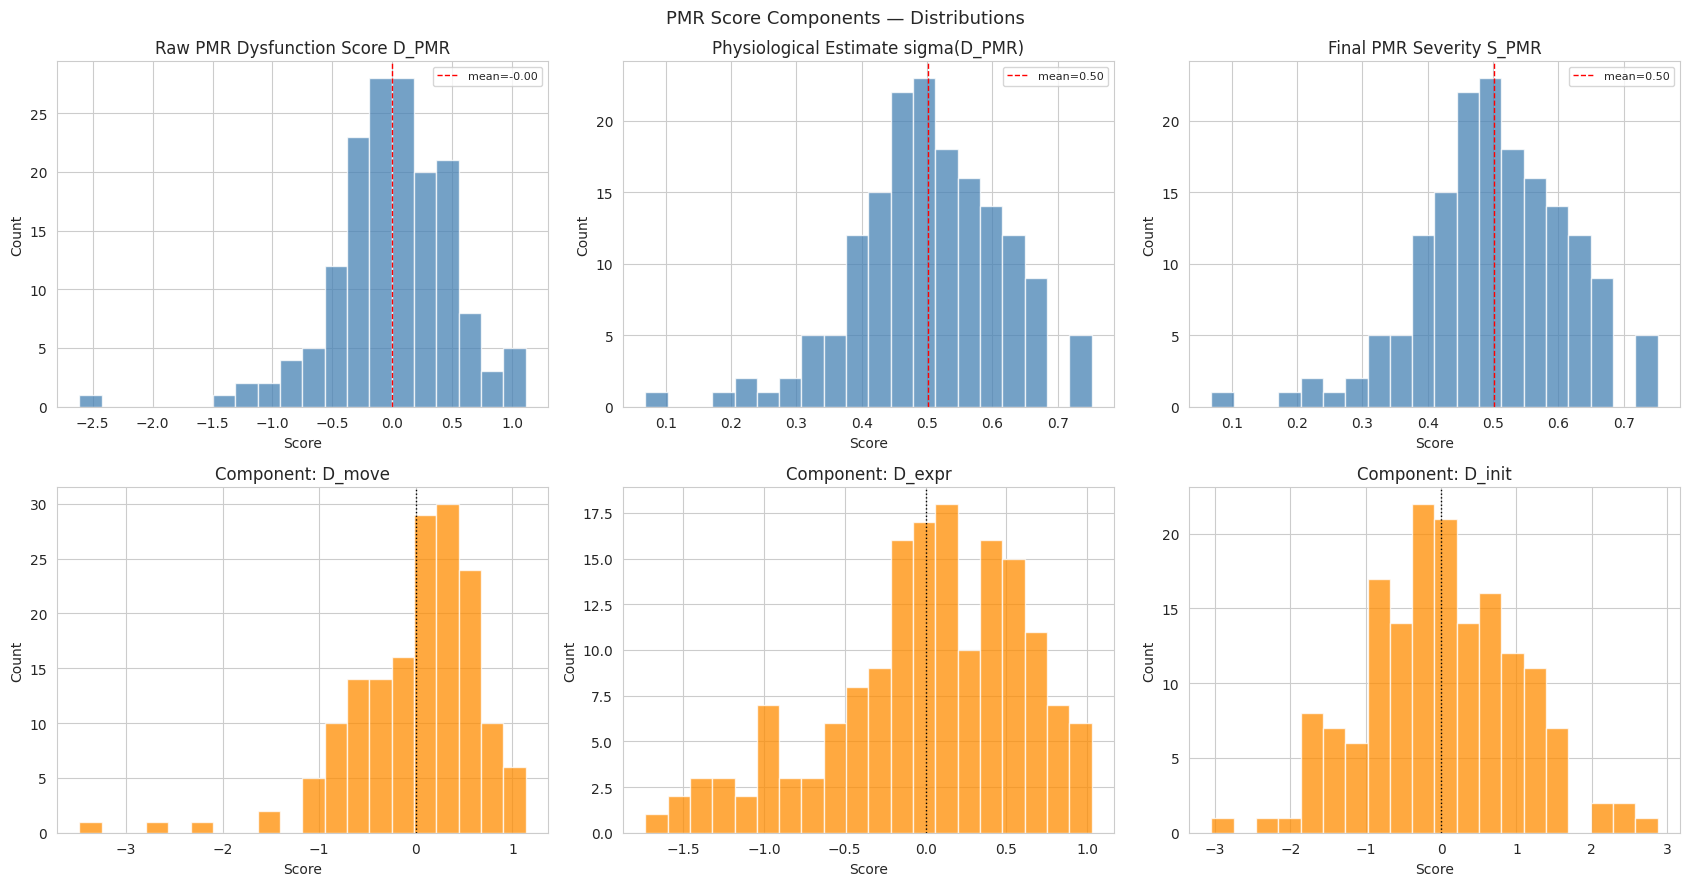

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, (col, title) in zip(axes[0], [
    ('D_PMR', 'Raw PMR Dysfunction Score D_PMR'),
    ('sigma_D_PMR', 'Physiological Estimate sigma(D_PMR)'),
    ('S_PMR', 'Final PMR Severity S_PMR')
]):
    ax.hist(df[col], bins=20, color='steelblue', alpha=0.75)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f'mean={df[col].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for ax, col in zip(axes[1], ['D_move', 'D_expr', 'D_init']):
    ax.hist(df[col], bins=20, color='darkorange', alpha=0.75)
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'Component: {col}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.suptitle('PMR Score Components — Distributions', fontsize=13)
plt.tight_layout()
plt.show()


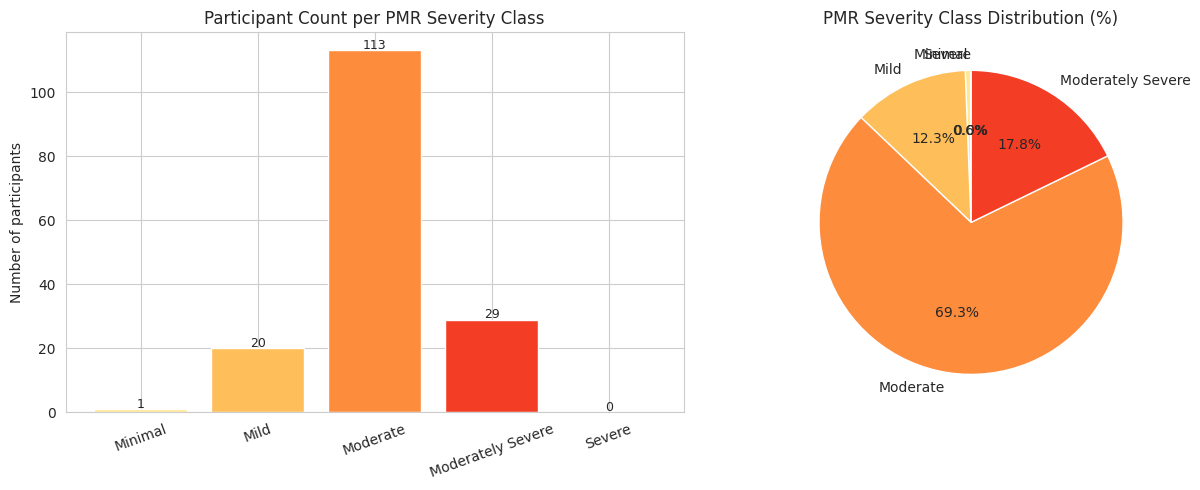

In [ ]:
order = SEVERITY_LABELS
palette = sns.color_palette('YlOrRd', n_colors=5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['PMR_class'].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=palette)
axes[0].set_title('Participant Count per PMR Severity Class')
axes[0].set_ylabel('Number of participants')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(int(v)), ha='center', fontsize=9)

axes[1].pie(counts.values, labels=order, autopct='%1.1f%%', colors=palette, startangle=90)
axes[1].set_title('PMR Severity Class Distribution (%)')

plt.tight_layout()
plt.show()


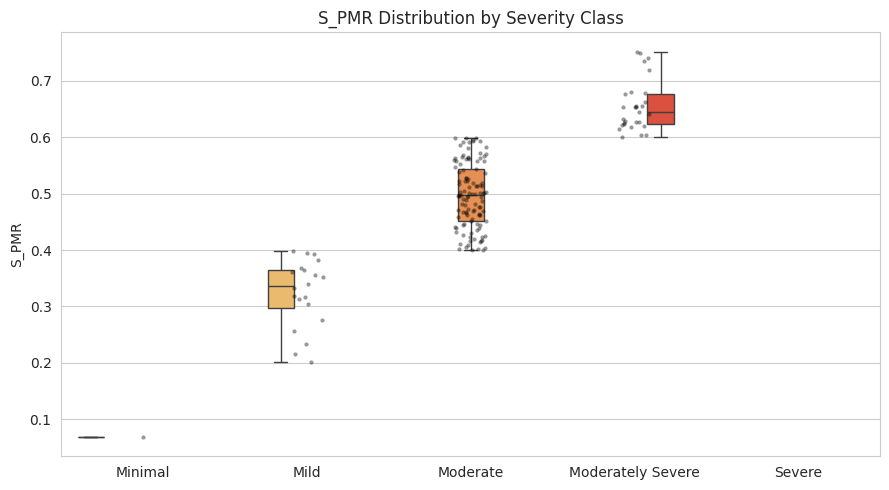

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='PMR_class', y='S_PMR', order=order, hue='PMR_class', palette=palette, legend=False, ax=ax)
sns.stripplot(data=df, x='PMR_class', y='S_PMR', order=order, color='black', alpha=0.4, size=3, ax=ax)
ax.set_title('S_PMR Distribution by Severity Class')
ax.set_xlabel('')
ax.set_ylabel('S_PMR')
plt.tight_layout()
plt.show()


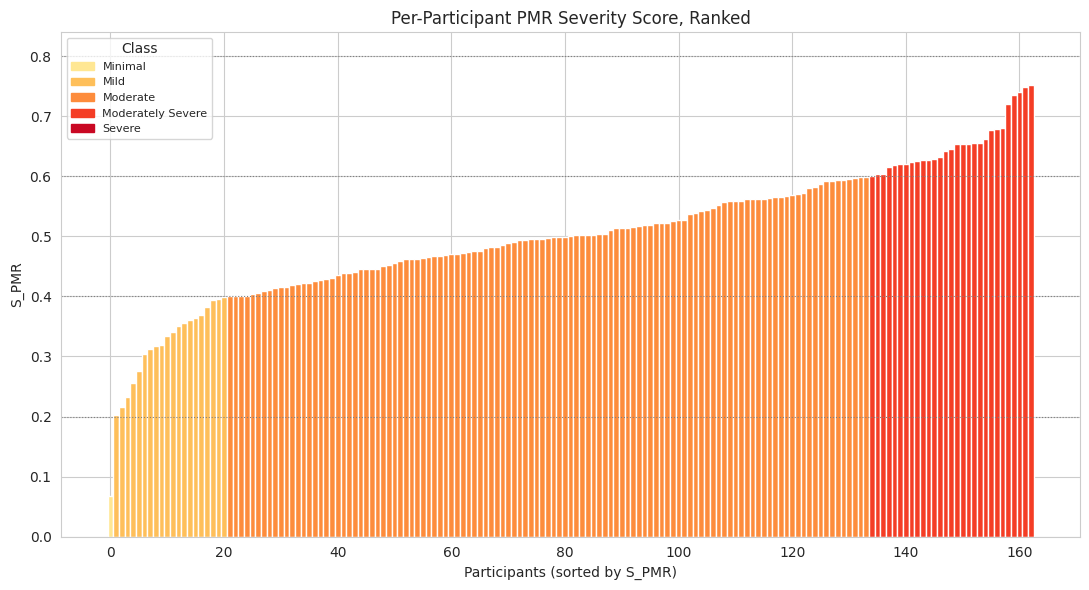

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
df_sorted = df.sort_values('S_PMR').reset_index(drop=True)
colors_map = dict(zip(order, palette))
bar_colors = df_sorted['PMR_class'].astype(str).map(colors_map)

ax.bar(range(len(df_sorted)), df_sorted['S_PMR'], color=bar_colors, width=1.0)
for edge, lbl in zip(SEVERITY_BINS[1:-1], SEVERITY_LABELS):
    ax.axhline(edge, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Participants (sorted by S_PMR)')
ax.set_ylabel('S_PMR')
ax.set_title('Per-Participant PMR Severity Score, Ranked')

handles = [plt.Rectangle((0,0),1,1, color=colors_map[l]) for l in order]
ax.legend(handles, order, title='Class', loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


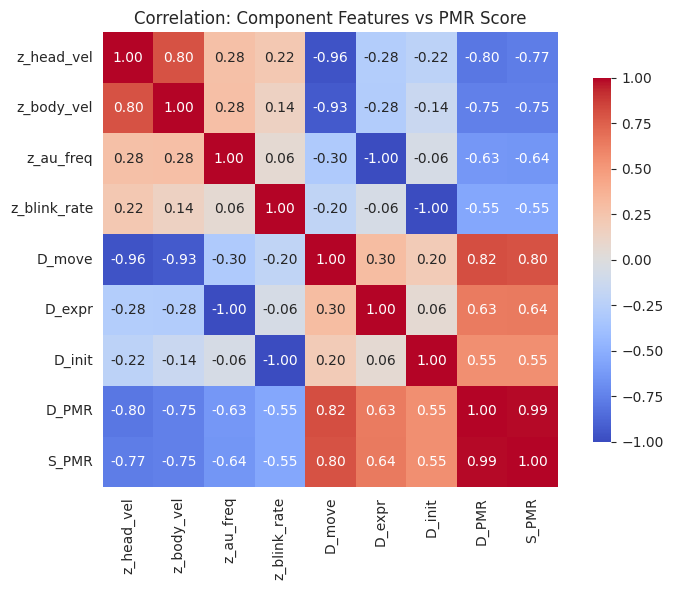

In [ ]:
feature_cols_for_corr = ['z_head_vel', 'z_body_vel', 'z_au_freq', 'z_blink_rate', 'D_move', 'D_expr', 'D_init', 'D_PMR', 'S_PMR']
corr = df[feature_cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation: Component Features vs PMR Score')
plt.tight_layout()
plt.show()


## 8. Summary table

In [ ]:
summary = df.groupby('PMR_class', observed=True)[['S_PMR', 'D_PMR', 'head_vel', 'body_vel', 'au_freq', 'blink_rate']].mean()
summary['n_participants'] = df.groupby('PMR_class', observed=True).size()
summary
